# Домашнее задание №1 — многослойный персептрон с нуля

## 1. Импорты

In [1]:
import gzip
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

SEED = 42
np.random.seed(SEED)


## 2. Загрузка Fashion-MNIST

In [2]:
class FashionMNIST:
    BASE_URL = (
        "https://raw.githubusercontent.com/"
        "zalandoresearch/fashion-mnist/master/data/fashion"
    )

    FILES = {
        "train_images": "train-images-idx3-ubyte.gz",
        "train_labels": "train-labels-idx1-ubyte.gz",
        "val_images": "t10k-images-idx3-ubyte.gz",
        "val_labels": "t10k-labels-idx1-ubyte.gz",
    }

    def __init__(self, root="fashion_mnist_data"):
        self.root = Path(root)
        self.root.mkdir(parents=True, exist_ok=True)

    def _download(self, filename):
        path = self.root / filename

        if not path.exists():
            url = f"{self.BASE_URL}/{filename}"
            print(f"Downloading {filename}...")
            urllib.request.urlretrieve(url, path)

        return path

    @staticmethod
    def _read_images(path):
        with gzip.open(path, "rb") as f:
            data = np.frombuffer(f.read(), dtype=np.uint8, offset=16)

        return data.reshape(-1, 28 * 28)

    @staticmethod
    def _read_labels(path):
        with gzip.open(path, "rb") as f:
            data = np.frombuffer(f.read(), dtype=np.uint8, offset=8)

        return data

    def load(self, dtype=np.float32):
        paths = {
            key: self._download(filename)
            for key, filename in self.FILES.items()
        }

        X_train = self._read_images(paths["train_images"]).astype(dtype) / 255.0
        y_train = self._read_labels(paths["train_labels"]).astype(np.int64)

        X_val = self._read_images(paths["val_images"]).astype(dtype) / 255.0
        y_val = self._read_labels(paths["val_labels"]).astype(np.int64)

        return X_train, y_train, X_val, y_val


dataset = FashionMNIST()

X_train, y_train, X_val, y_val = dataset.load()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:  ", X_val.shape)
print("y_val:  ", y_val.shape)
print("Pixel range:", X_train.min(), "-", X_train.max())
print("Classes:", np.unique(y_train))


X_train: (60000, 784)
y_train: (60000,)
X_val:   (10000, 784)
y_val:   (10000,)
Pixel range: 0.0 - 1.0
Classes: [0 1 2 3 4 5 6 7 8 9]


## 3. Реализация MLP

In [3]:
class MLP:
    def __init__(self, layers, activation = "relu", weight_init = "xavier", weight_init_std = 0.01,
                 constant_value = 0.01,
                 bias_init = "zero",
                 bias_init_std = 0.01,
                 dtype=np.float32, 
                 seed = 42):
        if len(layers) < 2:
            raise ValueError("layers должен содержать как минимум вход и выход.")

        if activation not in {"sigmoid", "tanh", "relu"}:
            raise ValueError(f"Unknown activation: {activation}")

        if weight_init not in {"constant", "normal", "xavier", "kaiming"}:
            raise ValueError(f"Unknown weight initialization: {weight_init}")

        if bias_init not in {"zero", "random"}:
            raise ValueError(f"Unknown bias initialization: {bias_init}")

        self.layers = layers
        self.activation_name = activation
        self.weight_init = weight_init
        self.weight_init_std = weight_init_std
        self.constant_value = constant_value
        self.bias_init = bias_init
        self.bias_init_std = bias_init_std
        self.dtype = dtype

        self.rng = np.random.default_rng(seed)

        self.weights = []
        self.biases = []

        self.dW = []
        self.db = []

        self.A = []
        self.Z = []

        for fan_in, fan_out in zip(layers[:-1], layers[1:]):
            W = self._init_weights(fan_in, fan_out)
            b = self._init_bias(fan_out)

            self.weights.append(W)
            self.biases.append(b)

        self.zero_grad()

    def _init_weights(self, fan_in, fan_out):
        if self.weight_init == "constant":
            W = np.full((fan_in, fan_out), self.constant_value, dtype=self.dtype)

        elif self.weight_init == "normal":
            W = self.rng.normal(loc=0.0, scale=self.weight_init_std, size=(fan_in, fan_out)).astype(self.dtype)

        elif self.weight_init == "xavier":
            std = np.sqrt(2.0 / (fan_in + fan_out))
            W = self.rng.normal(loc=0.0, scale=std, size=(fan_in, fan_out)).astype(self.dtype)

        elif self.weight_init == "kaiming":
            std = np.sqrt(2.0 / fan_in)
            W = self.rng.normal(loc=0.0, scale=std, size=(fan_in, fan_out)).astype(self.dtype)

        return W

    def _init_bias(self, fan_out):
        if self.bias_init == "zero":
            return np.zeros(fan_out, dtype=self.dtype)

        return self.rng.normal(loc=0.0, scale=self.bias_init_std, size=fan_out).astype(self.dtype)

    def _activation(self, Z):
        if self.activation_name == "sigmoid":
            Z_safe = np.clip(Z, -500, 500)
            return 1.0 / (1.0 + np.exp(-Z_safe))

        if self.activation_name == "tanh":
            return np.tanh(Z)

        return np.maximum(0.0, Z)

    def _activation_derivative(self, Z):
        if self.activation_name == "sigmoid":
            Z_safe = np.clip(Z, -500, 500)
            S = 1.0 / (1.0 + np.exp(-Z_safe))
            return S * (1.0 - S)

        if self.activation_name == "tanh":
            T = np.tanh(Z)
            return 1.0 - T ** 2

        return (Z > 0).astype(self.dtype)

    def forward(self, X):
        X = X.astype(self.dtype, copy=False)

        self.A = [X]
        self.Z = []

        A = X

        for i, (W, b) in enumerate(zip(self.weights, self.biases)):
            Z = A @ W + b
            self.Z.append(Z)

            if i < len(self.weights) - 1:
                A = self._activation(Z)
            else:
                A = Z

            self.A.append(A)

        return A

    def backward(self, dL_dlogits):
        dZ = dL_dlogits.astype(self.dtype, copy=False)

        for i in reversed(range(len(self.weights))):
            A_prev = self.A[i]
            W = self.weights[i]

            self.dW[i] = A_prev.T @ dZ
            self.db[i] = np.sum(dZ, axis=0)

            if i > 0:
                dA_prev = dZ @ W.T
                dZ = (
                    dA_prev
                    * self._activation_derivative(self.Z[i - 1])
                )

    def zero_grad(self):
        self.dW = [np.zeros_like(W) for W in self.weights]
        self.db = [np.zeros_like(b) for b in self.biases]

    def parameters(self):
        return list(zip(self.weights, self.biases))

    def predict(self, X):
        logits = self.forward(X)
        return np.argmax(softmax(logits), axis=1)


## 4. Softmax, cross-entropy, SGD и норма градиента

Градиент `dL/dlogits` для связки softmax + cross-entropy вычисляется вручную.
Усреднение по mini-batch выполняется здесь ровно один раз.


In [4]:
def softmax(logits):
    shifted = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(shifted)

    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)


def cross_entropy_loss(logits, y):
    probs = softmax(logits)
    n = logits.shape[0]

    return float(-np.mean(np.log(probs[np.arange(n), y] + 1e-12)))


def cross_entropy_with_grad(logits, y):
    probs = softmax(logits)
    n = logits.shape[0]

    loss = float(-np.mean(np.log(probs[np.arange(n), y] + 1e-12)))

    dlogits = probs.copy()
    dlogits[np.arange(n), y] -= 1.0
    dlogits /= n

    return loss, dlogits


def sgd_step(model, lr):
    for i in range(len(model.weights)):
        model.weights[i] -= lr * model.dW[i]
        model.biases[i] -= lr * model.db[i]


def gradient_l2_norm(model):
    total_squared = 0.0

    for grad in model.dW:
        total_squared += np.sum(grad.astype(np.float64) ** 2)

    for grad in model.db:
        total_squared += np.sum(grad.astype(np.float64) ** 2)

    return float(np.sqrt(total_squared))


## 5. Метрики, train/validation loop и визуализация

После каждой train-эпохи выполняется отдельный validation-проход без обновления параметров.

Сохраняются:

- train: loss, accuracy, macro precision, macro recall, macro F1, средняя L2-норма градиента по mini-batch;
- validation: loss, accuracy, macro precision, macro recall, macro F1.


In [5]:
def classification_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
    }


def evaluate_model(model, X, y, batch_size=1024):
    total_loss = 0.0
    predictions = []

    for start in range(0, len(X), batch_size):
        end = start + batch_size

        X_batch = X[start:end]
        y_batch = y[start:end]

        logits = model.forward(X_batch)

        total_loss += (cross_entropy_loss(logits, y_batch) * len(X_batch))

        predictions.append(np.argmax(logits, axis=1))

    y_pred = np.concatenate(predictions)

    metrics = classification_metrics(y, y_pred)
    metrics["loss"] = total_loss / len(X)

    return metrics


def train_model(model, X_train, y_train, X_val, y_val, batch_size, lr, epochs, seed=42, verbose=True):
    rng = np.random.default_rng(seed)
    n_samples = len(X_train)

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "train_precision": [],
        "train_recall": [],
        "train_f1": [],
        "train_grad_norm": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_precision": [],
        "val_recall": [],
        "val_f1": [],
    }

    for epoch in range(epochs):
        indices = rng.permutation(n_samples)

        batch_grad_norms = []

        for start in range(0, n_samples, batch_size):
            batch_idx = indices[start:start + batch_size]

            X_batch = X_train[batch_idx]
            y_batch = y_train[batch_idx]

            logits = model.forward(X_batch)
            _, dL_dlogits = cross_entropy_with_grad(logits, y_batch)

            model.zero_grad()
            model.backward(dL_dlogits)

            batch_grad_norms.append(gradient_l2_norm(model))

            sgd_step(model, lr)

        train_metrics = evaluate_model(model, X_train, y_train)

        val_metrics = evaluate_model(model, X_val, y_val)

        history["train_loss"].append(train_metrics["loss"])
        history["train_accuracy"].append(train_metrics["accuracy"])
        history["train_precision"].append(train_metrics["precision"])
        history["train_recall"].append(train_metrics["recall"])
        history["train_f1"].append(train_metrics["f1"])
        history["train_grad_norm"].append(float(np.mean(batch_grad_norms)))

        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["accuracy"])
        history["val_precision"].append(val_metrics["precision"])
        history["val_recall"].append(val_metrics["recall"])
        history["val_f1"].append(val_metrics["f1"])

        if verbose:
            print(
                f"Epoch {epoch + 1:2d}/{epochs} | "
                f"train loss={train_metrics['loss']:.4f} | "
                f"train acc={train_metrics['accuracy']:.4f} | "
                f"val loss={val_metrics['loss']:.4f} | "
                f"val acc={val_metrics['accuracy']:.4f} | "
                f"val F1={val_metrics['f1']:.4f} | "
                f"grad L2={history['train_grad_norm'][-1]:.4f}"
            )

    return history


In [6]:
def plot_metrics(history, title = "Training metrics"):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(3, 2, figsize=(14, 14))

    fig.suptitle(title, fontsize=16)

    pairs = [
        ("loss", "Loss"),
        ("accuracy", "Accuracy"),
        ("precision", "Macro Precision"),
        ("recall", "Macro Recall"),
        ("f1", "Macro F1"),
    ]

    for ax, (key, label) in zip(axes.flat[:5], pairs):
        ax.plot(
            epochs,
            history[f"train_{key}"],
            label=f"Train {label}")

        ax.plot(
            epochs,
            history[f"val_{key}"],
            label=f"Validation {label}")

        ax.set_xlabel("Epoch")
        ax.set_ylabel(label)
        ax.set_title(label)
        ax.legend()
        ax.grid(True, alpha=0.3)

    ax = axes.flat[5]

    ax.plot(
        epochs,
        history["train_grad_norm"],
        label="Train gradient L2 norm")

    ax.set_xlabel("Epoch")
    ax.set_ylabel("L2 norm")
    ax.set_title("Gradient L2 norm")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_comparison(named_results, history_key, title, ylabel):
    plt.figure(figsize=(10, 6))

    for label, result in named_results.items():
        values = result["history"][history_key]
        epochs = np.arange(1, len(values) + 1)

        plt.plot(
            epochs,
            values,
            label=label,
        )

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


## 6. Вспомогательные функции для экспериментов

Каждый запуск создаёт новую модель с тем же фиксированным seed.
Это позволяет проводить контролируемые сравнения.


In [7]:
def run_experiment(name, config, X_train, y_train, X_val, y_val, seed=42, hypothesis="Series 1", role="", 
                   verbose=True):
    print(name)

    print("layers: ", config["layers"])
    print("weight_init: ", config["weight_init"])
    print("activation: ", config["activation"])
    print("bias_init: ", config.get("bias_init", "zero"))
    print("batch_size: ", config["batch_size"])
    print("lr: ", config["lr"])
    print("epochs: ", config["epochs"])

    model = MLP(layers=config["layers"], activation=config["activation"], weight_init=config["weight_init"], 
                weight_init_std=config.get("weight_init_std", 0.01),
                constant_value=config.get("constant_value", 0.01),
                bias_init=config.get("bias_init", "zero"),
                bias_init_std=config.get("bias_init_std", 0.01), seed=seed)

    history = train_model(model=model, X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val,
                          batch_size=config["batch_size"],
                          lr=config["lr"],
                          epochs=config["epochs"],
                          seed=seed,
                          verbose=verbose)

    return {
        "name": name,
        "hypothesis": hypothesis,
        "role": role,
        "config": copy_config(config),
        "model": model,
        "history": history,
    }


def copy_config(config):
    return {
        key: (
            value.copy()
            if isinstance(value, list)
            else value
        )
        for key, value in config.items()
    }


def clone_result_reference(result, name, hypothesis, role):
    return {
        "name": name,
        "hypothesis": hypothesis,
        "role": role,
        "config": copy_config(result["config"]),
        "model": result["model"],
        "history": result["history"],
    }


In [8]:
def result_row(result, conclusion=""):
    config = result["config"]
    history = result["history"]

    weight_init_std = config.get("weight_init_std", 0.01) if config["weight_init"] == "normal" else np.nan
    bias_init = config.get("bias_init", "zero")
    bias_init_std = config.get("bias_init_std", 0.01) if bias_init == "random" else np.nan

    return {
        "experiment": result["name"],
        "hypothesis": result["hypothesis"],
        "role": result.get("role", ""),
        "architecture": str(config["layers"]),
        "init": config["weight_init"],
        "weight_init_std": weight_init_std,
        "activation": config["activation"],
        "bias_init": bias_init,
        "bias_init_std": bias_init_std,
        "batch": config["batch_size"],
        "lr": config["lr"],
        "epochs": config["epochs"],
        "train_loss": history["train_loss"][-1],
        "train_accuracy": history["train_accuracy"][-1],
        "train_precision": history["train_precision"][-1],
        "train_recall": history["train_recall"][-1],
        "train_f1": history["train_f1"][-1],
        "val_loss": history["val_loss"][-1],
        "val_accuracy": history["val_accuracy"][-1],
        "val_precision": history["val_precision"][-1],
        "val_recall": history["val_recall"][-1],
        "val_f1": history["val_f1"][-1],
        "grad_l2": history["train_grad_norm"][-1],
        "conclusion": conclusion or result.get("role", ""),
    }


def results_to_dataframe(results, conclusions=None):
    conclusions = conclusions or {}
    rows = [result_row(result, conclusions.get(result["name"], "")) for result in results]
    return pd.DataFrame(rows)


def histories_to_dataframe(results):
    rows = []

    for result in results:
        config = result["config"]
        history = result["history"]

        for epoch in range(len(history["train_loss"])):
            rows.append({
                "experiment": result["name"],
                "hypothesis": result["hypothesis"],
                "role": result.get("role", ""),
                "epoch": epoch + 1,
                "architecture": str(config["layers"]),
                "init": config["weight_init"],
                "activation": config["activation"],
                "bias_init": config.get("bias_init", "zero"),
                "batch": config["batch_size"],
                "lr": config["lr"],
                "train_loss": history["train_loss"][epoch],
                "train_accuracy": history["train_accuracy"][epoch],
                "train_precision": history["train_precision"][epoch],
                "train_recall": history["train_recall"][epoch],
                "train_f1": history["train_f1"][epoch],
                "train_grad_norm": history["train_grad_norm"][epoch],
                "val_loss": history["val_loss"][epoch],
                "val_accuracy": history["val_accuracy"][epoch],
                "val_precision": history["val_precision"][epoch],
                "val_recall": history["val_recall"][epoch],
                "val_f1": history["val_f1"][epoch],
            })

    return pd.DataFrame(rows)


# 7. Серия экспериментов 1 - обязательные конфигурации

In [9]:
mandatory_configs = {
    "S1_1": {
        "layers": [784, 100, 50, 10],
        "weight_init": "normal",
        "activation": "sigmoid",
        "bias_init": "zero",
        "batch_size": 16,
        "lr": 0.1,
        "epochs": 35,
    },

    "S1_2": {
        "layers": [784, 100, 50, 10],
        "weight_init": "normal",
        "activation": "sigmoid",
        "bias_init": "zero",
        "batch_size": 32,
        "lr": 0.01,
        "epochs": 15,
    },

    "S1_3": {
        "layers": [784, 392, 196, 98, 10],
        "weight_init": "xavier",
        "activation": "tanh",
        "bias_init": "zero",
        "batch_size": 32,
        "lr": 0.01,
        "epochs": 15,
    },

    "S1_4": {
        "layers": [784, 392, 196, 98, 49, 25, 10],
        "weight_init": "kaiming",
        "activation": "relu",
        "bias_init": "zero",
        "batch_size": 64,
        "lr": 0.01,
        "epochs": 15,
    },
}


In [10]:
mandatory_results = {}

for name, config in mandatory_configs.items():
    mandatory_results[name] = run_experiment(
        name=name,
        config=config,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        seed=SEED,
        hypothesis="Series 1",
        role="обязательная конфигурация",
    )


S1_1
layers:  [784, 100, 50, 10]
weight_init:  normal
activation:  sigmoid
bias_init:  zero
batch_size:  16
lr:  0.1
epochs:  35
Epoch  1/35 | train loss=1.2702 | train acc=0.5005 | val loss=1.2732 | val acc=0.5059 | val F1=0.4237 | grad L2=0.5758
Epoch  2/35 | train loss=0.6636 | train acc=0.7606 | val loss=0.6834 | val acc=0.7575 | val F1=0.7460 | grad L2=0.7245
Epoch  3/35 | train loss=0.5427 | train acc=0.8006 | val loss=0.5683 | val acc=0.7898 | val F1=0.7863 | grad L2=0.9129
Epoch  4/35 | train loss=0.4426 | train acc=0.8394 | val loss=0.4797 | val acc=0.8246 | val F1=0.8187 | grad L2=0.9882
Epoch  5/35 | train loss=0.4074 | train acc=0.8548 | val loss=0.4511 | val acc=0.8414 | val F1=0.8391 | grad L2=1.0109
Epoch  6/35 | train loss=0.3872 | train acc=0.8611 | val loss=0.4339 | val acc=0.8450 | val F1=0.8391 | grad L2=1.0227
Epoch  7/35 | train loss=0.3576 | train acc=0.8699 | val loss=0.4088 | val acc=0.8550 | val F1=0.8540 | grad L2=1.0142
Epoch  8/35 | train loss=0.3413 | trai

Epoch  1/15 | train loss=0.5398 | train acc=0.8096 | val loss=0.5651 | val acc=0.7959 | val F1=0.7898 | grad L2=3.8787
Epoch  2/15 | train loss=0.4846 | train acc=0.8274 | val loss=0.5213 | val acc=0.8120 | val F1=0.8081 | grad L2=3.7848
Epoch  3/15 | train loss=0.5008 | train acc=0.8189 | val loss=0.5403 | val acc=0.8075 | val F1=0.8080 | grad L2=3.6306
Epoch  4/15 | train loss=0.3822 | train acc=0.8636 | val loss=0.4259 | val acc=0.8466 | val F1=0.8425 | grad L2=3.4565
Epoch  5/15 | train loss=0.3698 | train acc=0.8680 | val loss=0.4204 | val acc=0.8475 | val F1=0.8446 | grad L2=3.3699
Epoch  6/15 | train loss=0.3818 | train acc=0.8636 | val loss=0.4401 | val acc=0.8451 | val F1=0.8379 | grad L2=3.3085
Epoch  7/15 | train loss=0.3283 | train acc=0.8830 | val loss=0.3886 | val acc=0.8641 | val F1=0.8636 | grad L2=3.2172
Epoch  8/15 | train loss=0.3174 | train acc=0.8856 | val loss=0.3830 | val acc=0.8616 | val F1=0.8615 | grad L2=3.2177
Epoch  9/15 | train loss=0.3047 | train acc=0.88

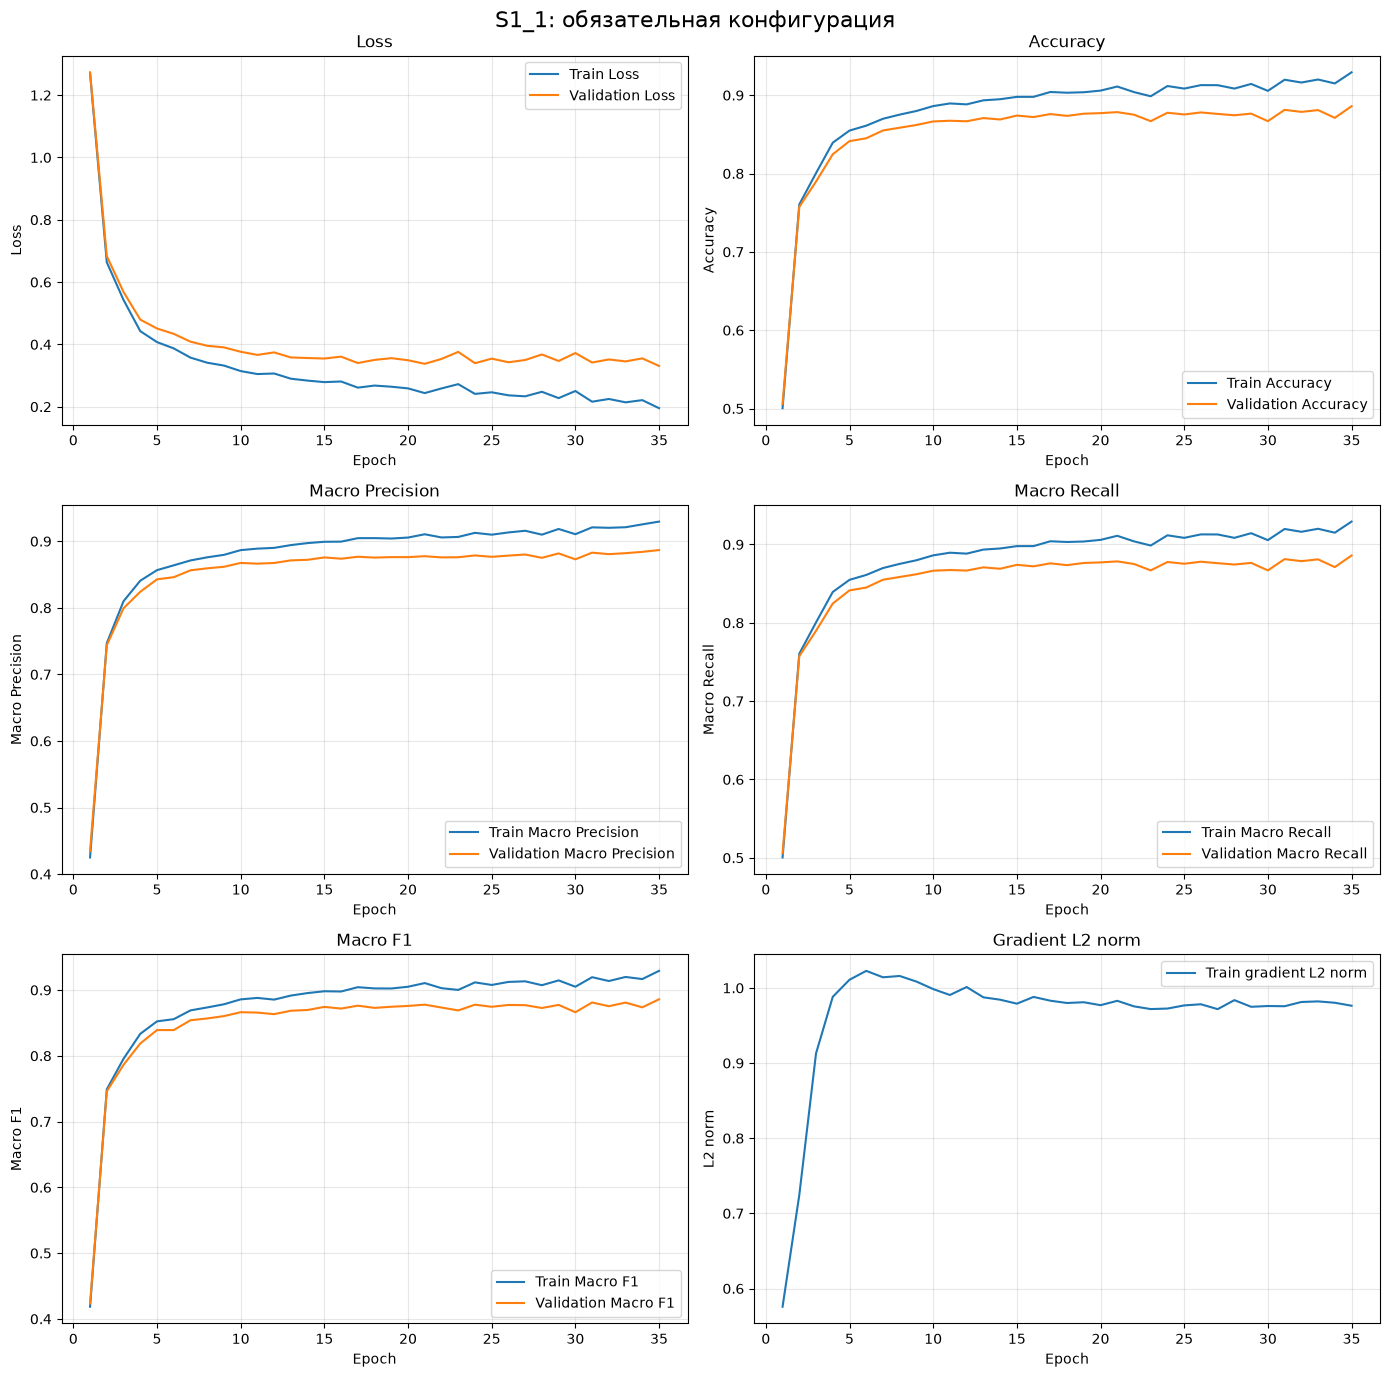

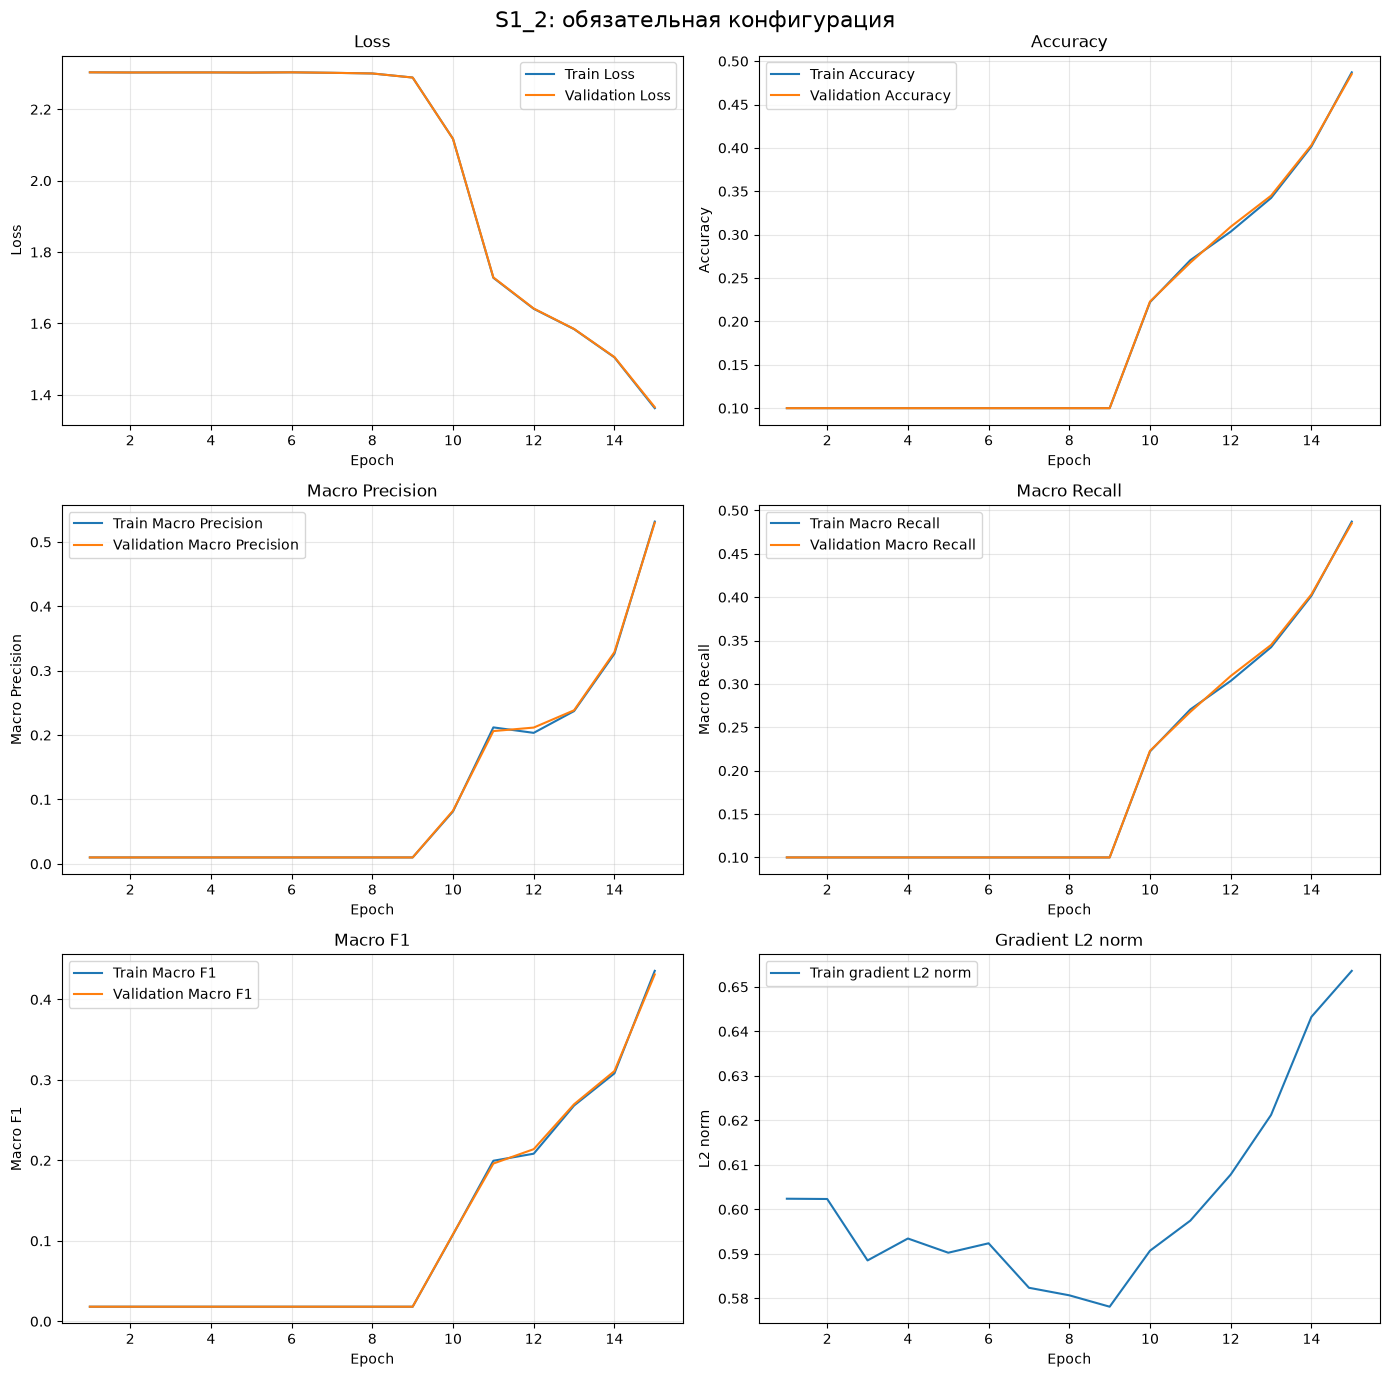

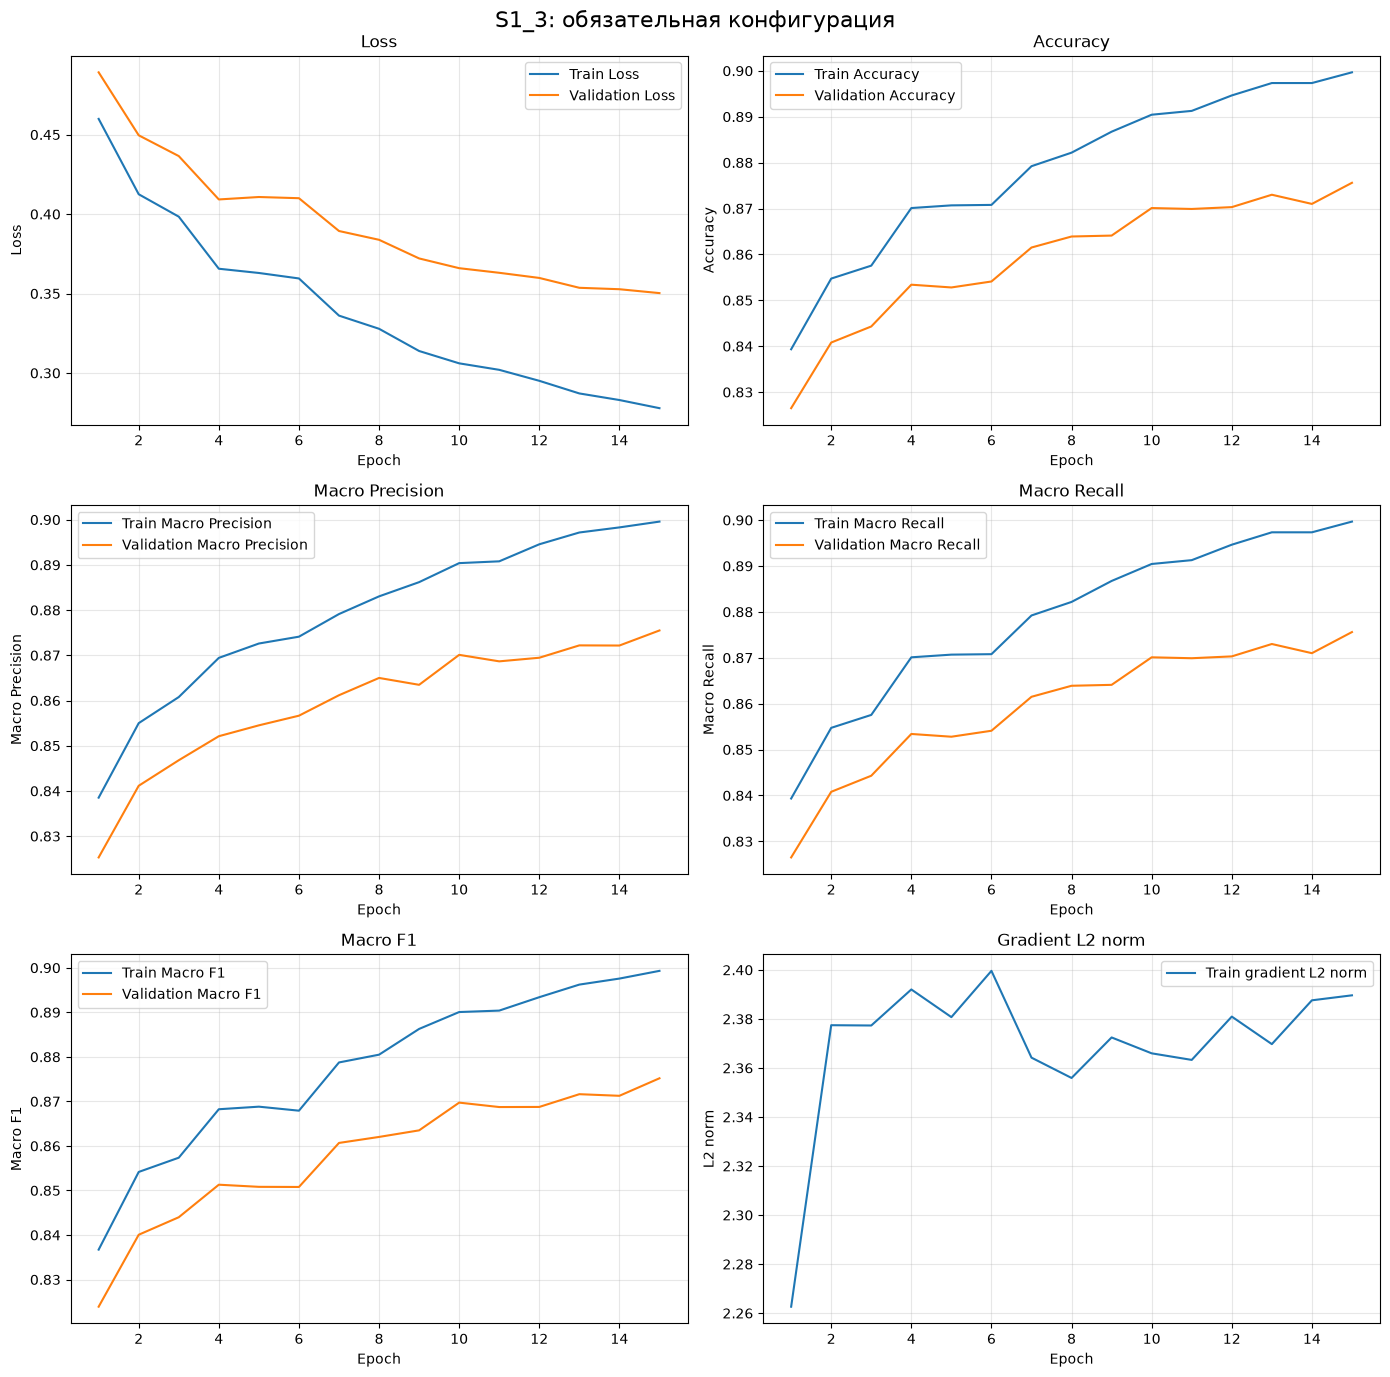

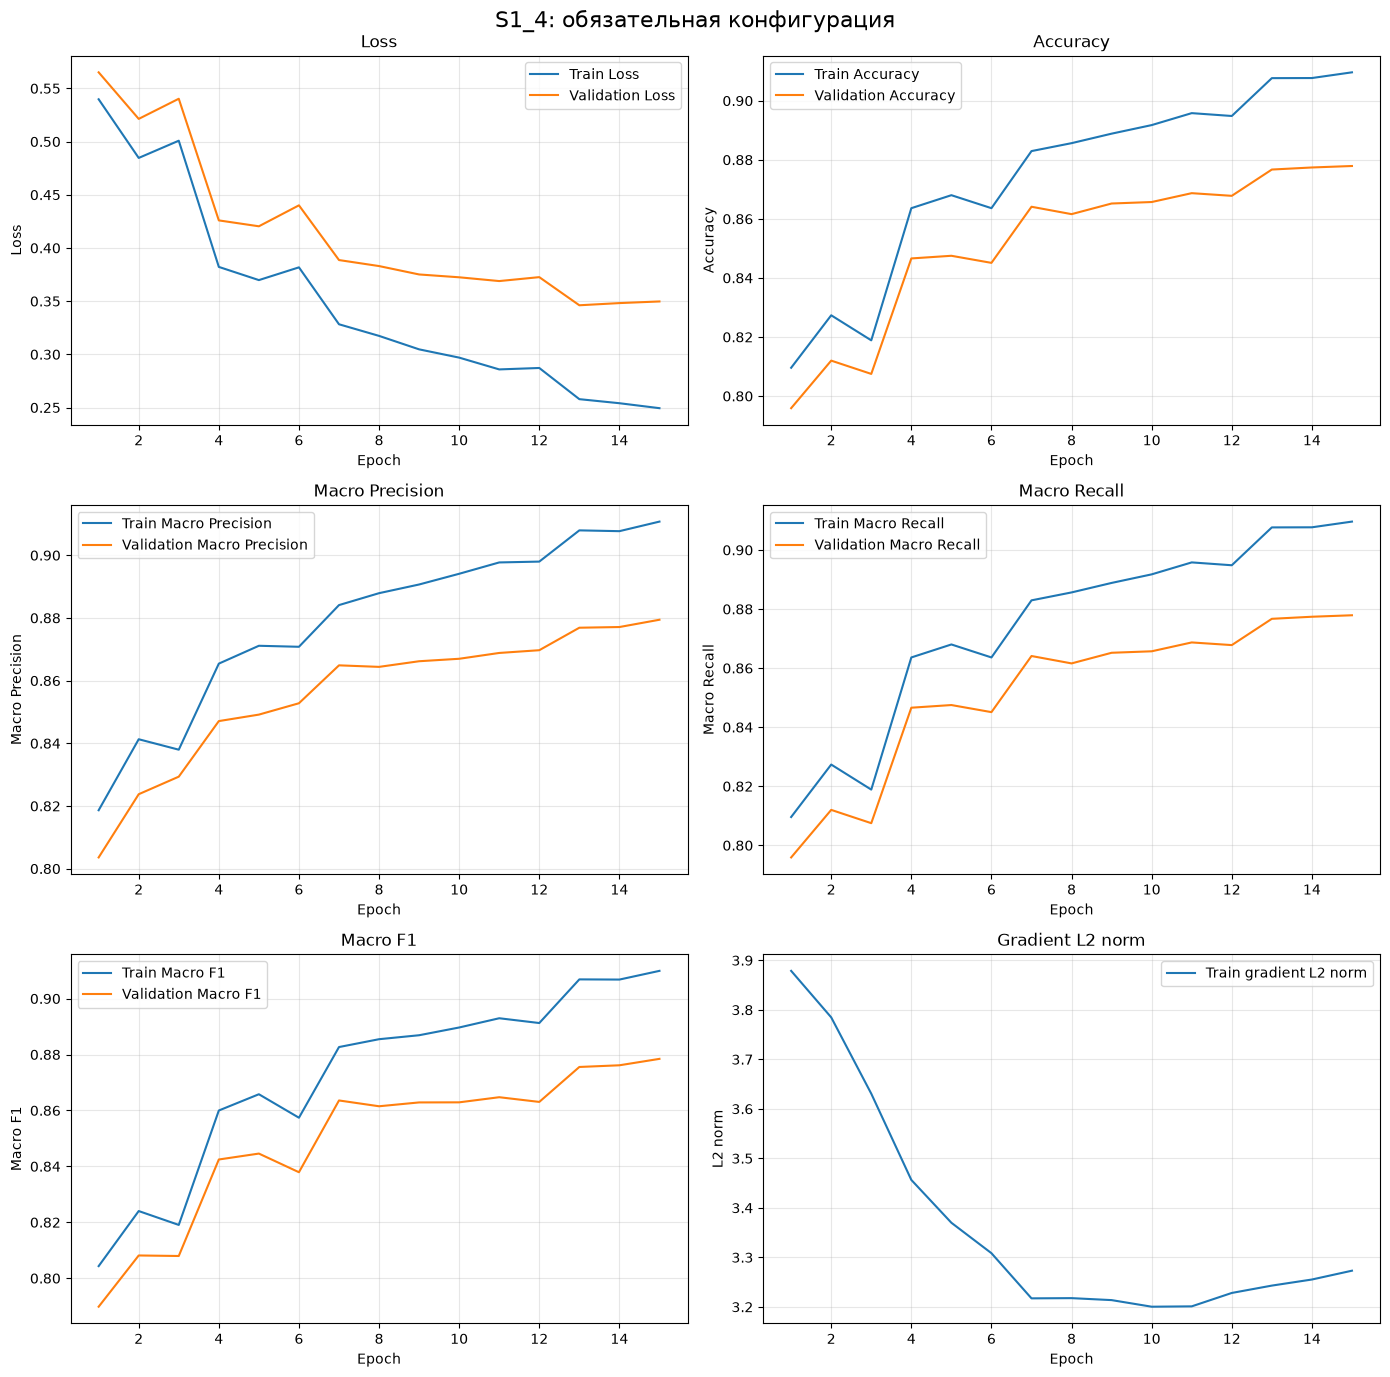

In [11]:
for name, result in mandatory_results.items():
    plot_metrics(result["history"], title=f"{name}: обязательная конфигурация")


In [12]:
mandatory_df = results_to_dataframe(list(mandatory_results.values()))
mandatory_df


,experiment,hypothesis,role,architecture,init,weight_init_std,activation,bias_init,bias_init_std,batch,...,train_precision,train_recall,train_f1,val_loss,val_accuracy,val_precision,val_recall,val_f1,grad_l2,conclusion
0,S1_1,Series 1,обязательная конфигурация,"[784, 100, 50, 10]",normal,0.01,sigmoid,zero,NaN,16,...,0.929562,0.929200,0.929149,0.330851,0.8859,0.886778,0.8859,0.885940,0.976321,обязательная конфигурация
1,S1_2,Series 1,обязательная конфигурация,"[784, 100, 50, 10]",normal,0.01,sigmoid,zero,NaN,32,...,0.531648,0.487100,0.435563,1.365696,0.4851,0.529849,0.4851,0.431154,0.653599,обязательная конфигурация
2,S1_3,Series 1,обязательная конфигурация,"[784, 392, 196, 98, 10]",xavier,NaN,tanh,zero,NaN,32,...,0.899580,0.899667,0.899313,0.350274,0.8756,0.875499,0.8756,0.875192,2.389627,обязательная конфигурация
3,S1_4,Series 1,обязательная конфигурация,"[784, 392, 196, 98, 49, 25, 10]",kaiming,NaN,relu,zero,NaN,64,...,0.910746,0.909617,0.909926,0.349736,0.8779,0.879430,0.8779,0.878454,3.273107,обязательная конфигурация


# 8. Серия экспериментов 2 - проверка гипотез

Здесь выбраны №1, №4 и №6 гипотезы

## H1. Sigmoid и глубокая сеть

**Гипотеза:** при одинаковой глубокой архитектуре и одинаковых параметрах обучения sigmoid приводит к менее стабильному обучению по сравнению с tanh или ReLU.

**Ожидаемый результат до запуска:** у sigmoid ожидаем более медленное уменьшение loss, более низкие validation metrics и/или менее благоприятную динамику нормы градиента.

Контроль параметров:

- архитектура: [784, 392, 196, 98, 10];
- initialization: Xavier;
- batch size: 32;
- learning rate: 0.01;
- epochs: 15;
- bias: zero;
- seed: 42.

In [13]:
h1_sigmoid_config = {**mandatory_configs["S1_3"], "activation": "sigmoid"}

h1_relu_config = {**mandatory_configs["S1_3"], "activation": "relu"}


h1_sigmoid = run_experiment(name="H1_sigmoid", config=h1_sigmoid_config, X_train=X_train,
                            y_train=y_train,
                            X_val=X_val, 
                            y_val=y_val,
                            seed=SEED, 
                            hypothesis="H1",
                            role="эксперимент: sigmoid")

h1_tanh = clone_result_reference(mandatory_results["S1_3"], name="H1_tanh_reuse_S1_3", hypothesis="H1",
                                 role="контроль: tanh; переиспользован S1_3")

h1_relu = run_experiment(name="H1_relu", config=h1_relu_config, X_train=X_train, y_train=y_train,
                         X_val=X_val,
                         y_val=y_val, 
                         seed=SEED, 
                         hypothesis="H1", 
                         role="эксперимент: ReLU")

h1_results = {"sigmoid": h1_sigmoid, "tanh (S1_3)": h1_tanh, "ReLU": h1_relu}


H1_sigmoid
layers:  [784, 392, 196, 98, 10]
weight_init:  xavier
activation:  sigmoid
bias_init:  zero
batch_size:  32
lr:  0.01
epochs:  15
Epoch  1/15 | train loss=2.2287 | train acc=0.2572 | val loss=2.2288 | val acc=0.2587 | val F1=0.1765 | grad L2=0.9715
Epoch  2/15 | train loss=1.7631 | train acc=0.4250 | val loss=1.7642 | val acc=0.4251 | val F1=0.3185 | grad L2=0.9728
Epoch  3/15 | train loss=1.2971 | train acc=0.5718 | val loss=1.3003 | val acc=0.5691 | val F1=0.5272 | grad L2=0.8996
Epoch  4/15 | train loss=1.0988 | train acc=0.6062 | val loss=1.1028 | val acc=0.6025 | val F1=0.5769 | grad L2=0.8707
Epoch  5/15 | train loss=0.9860 | train acc=0.6360 | val loss=0.9933 | val acc=0.6322 | val F1=0.6170 | grad L2=0.8530
Epoch  6/15 | train loss=0.9061 | train acc=0.6594 | val loss=0.9141 | val acc=0.6594 | val F1=0.6270 | grad L2=0.8514
Epoch  7/15 | train loss=0.8388 | train acc=0.7010 | val loss=0.8480 | val acc=0.6935 | val F1=0.6913 | grad L2=0.8490
Epoch  8/15 | train loss=0

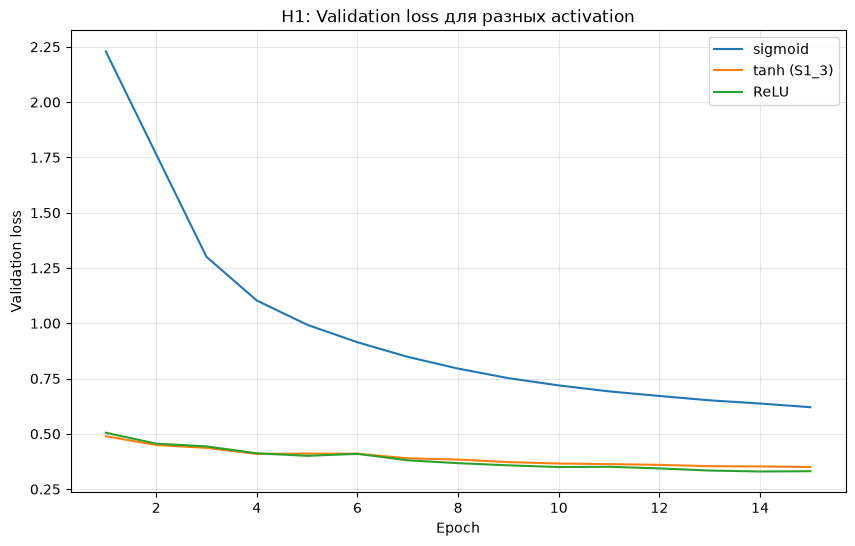

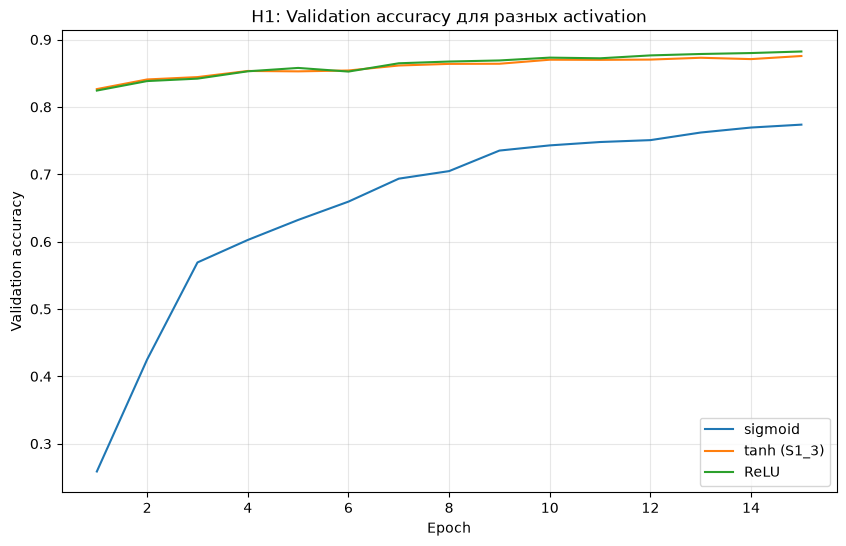

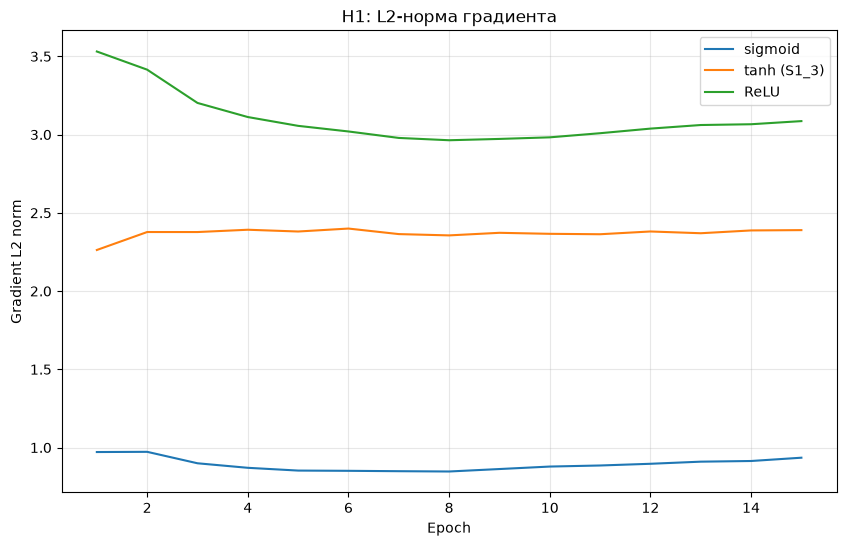

In [14]:
plot_comparison(h1_results, "val_loss", "H1: Validation loss для разных activation", "Validation loss")

plot_comparison(h1_results, "val_accuracy", "H1: Validation accuracy для разных activation", "Validation accuracy")

plot_comparison(h1_results, "train_grad_norm", "H1: L2-норма градиента", "Gradient L2 norm")


In [15]:
def analyze_h1(h1_results):
    sigmoid = h1_results["sigmoid"]["history"]
    tanh_hist = h1_results["tanh (S1_3)"]["history"]
    relu_hist = h1_results["ReLU"]["history"]

    sigmoid_acc = sigmoid["val_accuracy"][-1]
    tanh_acc = tanh_hist["val_accuracy"][-1]
    relu_acc = relu_hist["val_accuracy"][-1]

    sigmoid_loss = sigmoid["val_loss"][-1]
    tanh_loss = tanh_hist["val_loss"][-1]
    relu_loss = relu_hist["val_loss"][-1]

    worse_accuracy = sigmoid_acc < tanh_acc and sigmoid_acc < relu_acc
    worse_loss = sigmoid_loss > tanh_loss and sigmoid_loss > relu_loss

    if worse_accuracy and worse_loss:
        verdict = "Гипотеза H1 подтверждается."
    elif worse_accuracy or worse_loss:
        verdict = "Гипотеза H1 подтверждается частично: не все показатели дают одинаковый вывод."
    else:
        verdict = "Полученные результаты не подтверждают H1."

    conclusion = (
        f"{verdict} Final val accuracy: sigmoid={sigmoid_acc:.4f}, tanh={tanh_acc:.4f}, ReLU={relu_acc:.4f}; "
        f"final val loss: sigmoid={sigmoid_loss:.4f}, tanh={tanh_loss:.4f}, ReLU={relu_loss:.4f}."
    )

    print(conclusion)
    return conclusion


h1_conclusion = analyze_h1(h1_results)
h1_conclusions = {"H1_sigmoid": h1_conclusion, "H1_tanh_reuse_S1_3": h1_conclusion, "H1_relu": h1_conclusion}
h1_df = results_to_dataframe([h1_sigmoid, h1_tanh, h1_relu], conclusions=h1_conclusions)
h1_df


Гипотеза H1 подтверждается. Final val accuracy: sigmoid=0.7737, tanh=0.8756, ReLU=0.8823; final val loss: sigmoid=0.6205, tanh=0.3503, ReLU=0.3310.


,experiment,hypothesis,role,architecture,init,weight_init_std,activation,bias_init,bias_init_std,batch,...,train_precision,train_recall,train_f1,val_loss,val_accuracy,val_precision,val_recall,val_f1,grad_l2,conclusion
0,H1_sigmoid,H1,эксперимент: sigmoid,"[784, 392, 196, 98, 10]",xavier,NaN,sigmoid,zero,NaN,32,...,0.773381,0.780900,0.772872,0.620481,0.7737,0.766851,0.7737,0.766939,0.935232,Гипотеза H1 подтверждается. Final val accuracy...
1,H1_tanh_reuse_S1_3,H1,контроль: tanh; переиспользован S1_3,"[784, 392, 196, 98, 10]",xavier,NaN,tanh,zero,NaN,32,...,0.899580,0.899667,0.899313,0.350274,0.8756,0.875499,0.8756,0.875192,2.389627,Гипотеза H1 подтверждается. Final val accuracy...
2,H1_relu,H1,эксперимент: ReLU,"[784, 392, 196, 98, 10]",xavier,NaN,relu,zero,NaN,32,...,0.912948,0.913133,0.912777,0.331024,0.8823,0.882045,0.8823,0.881960,3.086235,Гипотеза H1 подтверждается. Final val accuracy...


## H4. Нулевая инициализация смещений

**Гипотеза:** при корректной инициализации весов b = 0 при старте не мешает обучению и не должно существенно ухудшать результат относительно небольших случайных bias.

**Ожидаемый результат до запуска:** итоговые validation accuracy и macro F1 должны быть близкими.

Контроль параметров:

- архитектура: [784, 392, 196, 98, 49, 25, 10];
- Kaiming;
- ReLU;
- batch size: 64;
- learning rate: 0.01;
- epochs: 15;
- seed: 42.


In [16]:
h4_zero = clone_result_reference(mandatory_results["S1_4"], name="H4_bias_zero_reuse_S1_4",
                                 hypothesis="H4", role="контроль: b=0; переиспользован S1_4")

h4_random_config = {**mandatory_configs["S1_4"], "bias_init": "random",
                    "bias_init_std": 0.01}

h4_random = run_experiment(name="H4_bias_random", config=h4_random_config, X_train=X_train,
                           y_train=y_train,
                           X_val=X_val,
                           y_val=y_val,
                           seed=SEED,
                           hypothesis="H4", role="эксперимент: b ~ N(0, 0.01)")

h4_results = {"bias = 0 (S1_4)": h4_zero, "random bias": h4_random}


H4_bias_random
layers:  [784, 392, 196, 98, 49, 25, 10]
weight_init:  kaiming
activation:  relu
bias_init:  random
batch_size:  64
lr:  0.01
epochs:  15
Epoch  1/15 | train loss=0.5076 | train acc=0.8223 | val loss=0.5335 | val acc=0.8103 | val F1=0.8063 | grad L2=4.3789
Epoch  2/15 | train loss=0.4607 | train acc=0.8338 | val loss=0.4955 | val acc=0.8207 | val F1=0.8177 | grad L2=3.8300
Epoch  3/15 | train loss=0.4443 | train acc=0.8408 | val loss=0.4894 | val acc=0.8230 | val F1=0.8237 | grad L2=3.5170
Epoch  4/15 | train loss=0.4017 | train acc=0.8560 | val loss=0.4495 | val acc=0.8383 | val F1=0.8316 | grad L2=3.4482
Epoch  5/15 | train loss=0.3558 | train acc=0.8719 | val loss=0.4094 | val acc=0.8512 | val F1=0.8500 | grad L2=3.3441
Epoch  6/15 | train loss=0.3690 | train acc=0.8678 | val loss=0.4268 | val acc=0.8464 | val F1=0.8388 | grad L2=3.3075
Epoch  7/15 | train loss=0.3232 | train acc=0.8828 | val loss=0.3888 | val acc=0.8639 | val F1=0.8633 | grad L2=3.1807
Epoch  8/15 | 

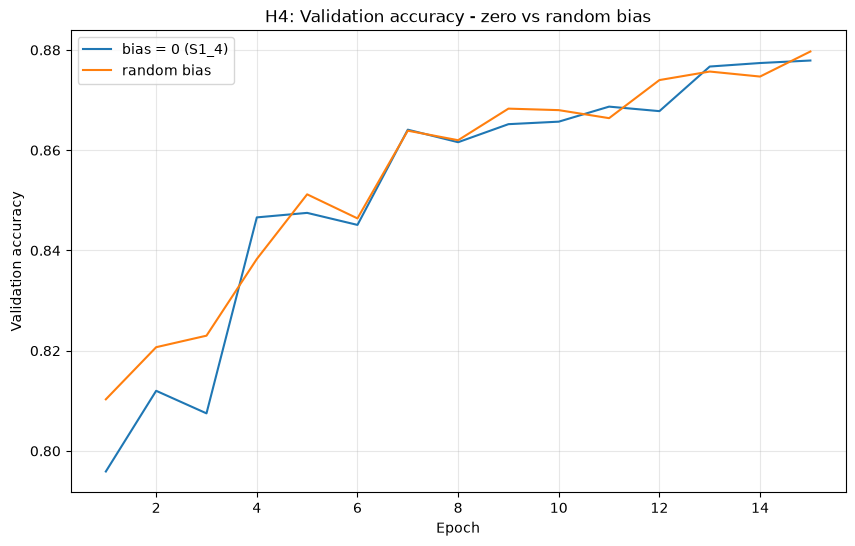

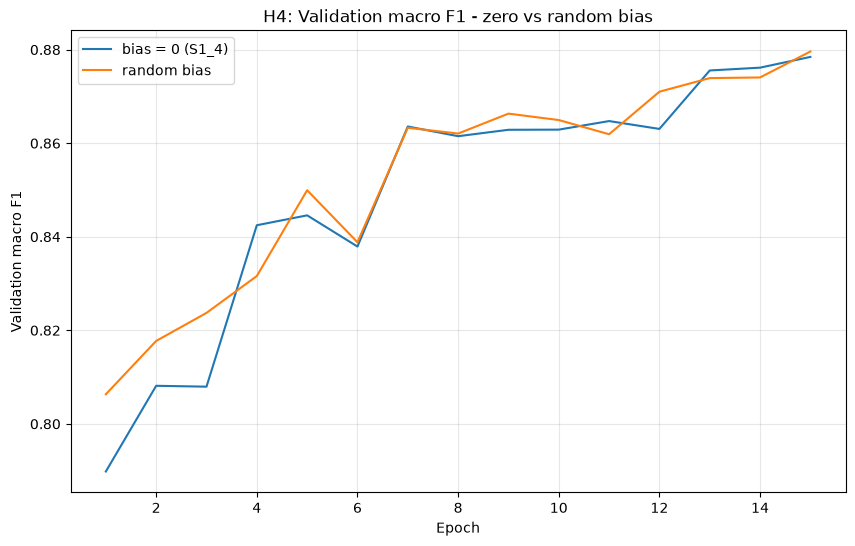

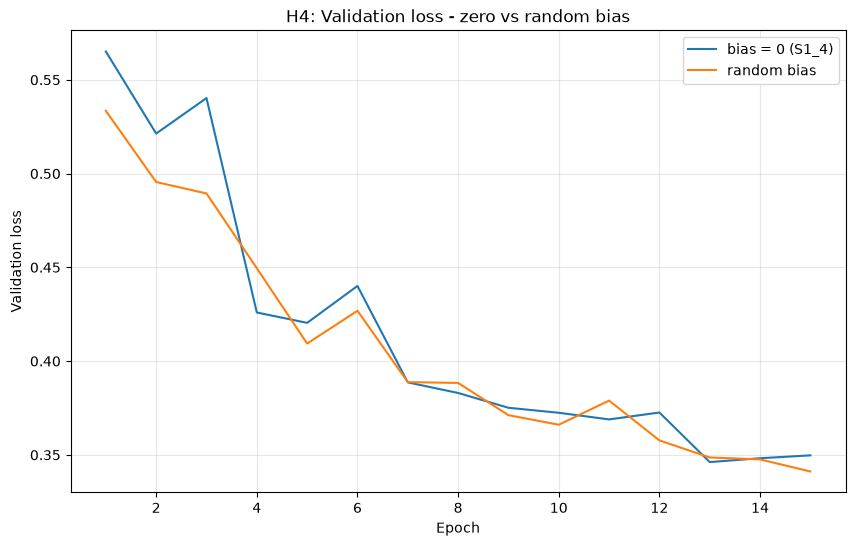

In [17]:
plot_comparison(h4_results, "val_accuracy", "H4: Validation accuracy - zero vs random bias", "Validation accuracy")

plot_comparison(h4_results, "val_f1", "H4: Validation macro F1 - zero vs random bias", "Validation macro F1")

plot_comparison(h4_results, "val_loss", "H4: Validation loss - zero vs random bias", "Validation loss")


In [18]:
def analyze_h4(h4_results, tolerance=0.01):
    zero_hist = h4_results["bias = 0 (S1_4)"]["history"]
    random_hist = h4_results["random bias"]["history"]

    zero_acc = zero_hist["val_accuracy"][-1]
    random_acc = random_hist["val_accuracy"][-1]
    zero_f1 = zero_hist["val_f1"][-1]
    random_f1 = random_hist["val_f1"][-1]

    acc_drop = random_acc - zero_acc
    f1_drop = random_f1 - zero_f1

    if acc_drop <= tolerance and f1_drop <= tolerance:
        verdict = "Гипотеза H4 подтверждается: нулевые bias не дали существенного ухудшения."
    else:
        verdict = f"Гипотеза H4 не подтверждается при выбранном пороге существенности {tolerance:.2f}."

    conclusion = (
        f"{verdict} Val accuracy: zero={zero_acc:.4f}, random={random_acc:.4f}; "
        f"macro F1: zero={zero_f1:.4f}, random={random_f1:.4f}."
    )

    print(conclusion)
    return conclusion


h4_conclusion = analyze_h4(h4_results)
h4_conclusions = {"H4_bias_zero_reuse_S1_4": h4_conclusion, "H4_bias_random": h4_conclusion}
h4_df = results_to_dataframe([h4_zero, h4_random], conclusions=h4_conclusions)
h4_df


Гипотеза H4 подтверждается: нулевые bias не дали существенного ухудшения. Val accuracy: zero=0.8779, random=0.8797; macro F1: zero=0.8785, random=0.8796.


,experiment,hypothesis,role,architecture,init,weight_init_std,activation,bias_init,bias_init_std,batch,...,train_precision,train_recall,train_f1,val_loss,val_accuracy,val_precision,val_recall,val_f1,grad_l2,conclusion
0,H4_bias_zero_reuse_S1_4,H4,контроль: b=0; переиспользован S1_4,"[784, 392, 196, 98, 49, 25, 10]",kaiming,NaN,relu,zero,NaN,64,...,0.910746,0.909617,0.909926,0.349736,0.8779,0.879430,0.8779,0.878454,3.273107,Гипотеза H4 подтверждается: нулевые bias не да...
1,H4_bias_random,H4,"эксперимент: b ~ N(0, 0.01)","[784, 392, 196, 98, 49, 25, 10]",kaiming,NaN,relu,random,0.01,64,...,0.912402,0.912250,0.912186,0.341128,0.8797,0.880017,0.8797,0.879611,3.254826,Гипотеза H4 подтверждается: нулевые bias не да...


## H6. Размер mini-batch

**Гипотеза:** маленький mini-batch даёт более шумную динамику оптимизации, но не обязательно приводит к худшему итоговому качеству.

**Ожидаемый результат до запуска:** при batch=16 ожидаем более выраженные колебания train loss / gradient norm, чем при batch=64 или 256. Финальная validation accuracy при этом может оставаться сопоставимой.

Контроль параметров:

- та же архитектура;
- Kaiming;
- ReLU;
- learning rate: 0.01;
- epochs: 15;
- zero bias;
- seed: 42.

In [19]:
h6_batch16_config = {**mandatory_configs["S1_4"], "batch_size": 16}

h6_batch256_config = {**mandatory_configs["S1_4"], "batch_size": 256}


h6_batch16 = run_experiment(name="H6_batch16", config=h6_batch16_config, X_train=X_train,
                            y_train=y_train,
                            X_val=X_val,
                            y_val=y_val,
                            seed=SEED,
                            hypothesis="H6",
                            role="эксперимент: batch=16")

h6_batch64 = clone_result_reference(mandatory_results["S1_4"], name="H6_batch64_reuse_S1_4",
                                    hypothesis="H6",
                                    role="контроль: batch=64; переиспользован S1_4")

h6_batch256 = run_experiment(name="H6_batch256", config=h6_batch256_config, X_train=X_train,
                             y_train=y_train,
                             X_val=X_val,
                             y_val=y_val,
                             seed=SEED,
                             hypothesis="H6",
                             role="эксперимент: batch=256")

h6_results = {"batch=16": h6_batch16, "batch=64 (S1_4)": h6_batch64, "batch=256": h6_batch256}


H6_batch16
layers:  [784, 392, 196, 98, 49, 25, 10]
weight_init:  kaiming
activation:  relu
bias_init:  zero
batch_size:  16
lr:  0.01
epochs:  15
Epoch  1/15 | train loss=0.4143 | train acc=0.8512 | val loss=0.4498 | val acc=0.8374 | val F1=0.8321 | grad L2=5.1425
Epoch  2/15 | train loss=0.3577 | train acc=0.8679 | val loss=0.4106 | val acc=0.8495 | val F1=0.8511 | grad L2=4.5138
Epoch  3/15 | train loss=0.3665 | train acc=0.8659 | val loss=0.4274 | val acc=0.8466 | val F1=0.8468 | grad L2=4.3105
Epoch  4/15 | train loss=0.2943 | train acc=0.8917 | val loss=0.3641 | val acc=0.8665 | val F1=0.8639 | grad L2=4.2270
Epoch  5/15 | train loss=0.2944 | train acc=0.8919 | val loss=0.3737 | val acc=0.8646 | val F1=0.8636 | grad L2=4.1880
Epoch  6/15 | train loss=0.2780 | train acc=0.8963 | val loss=0.3600 | val acc=0.8678 | val F1=0.8643 | grad L2=4.1764
Epoch  7/15 | train loss=0.2644 | train acc=0.9018 | val loss=0.3537 | val acc=0.8752 | val F1=0.8752 | grad L2=4.1562
Epoch  8/15 | train 

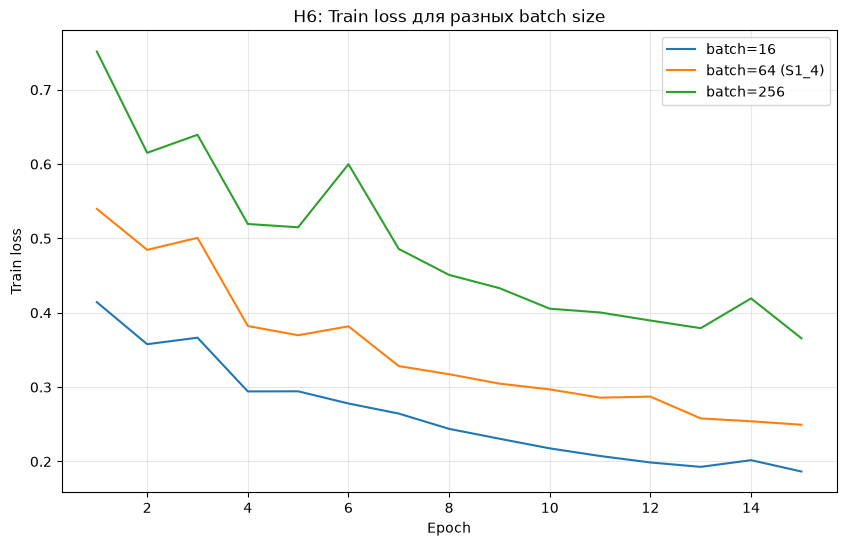

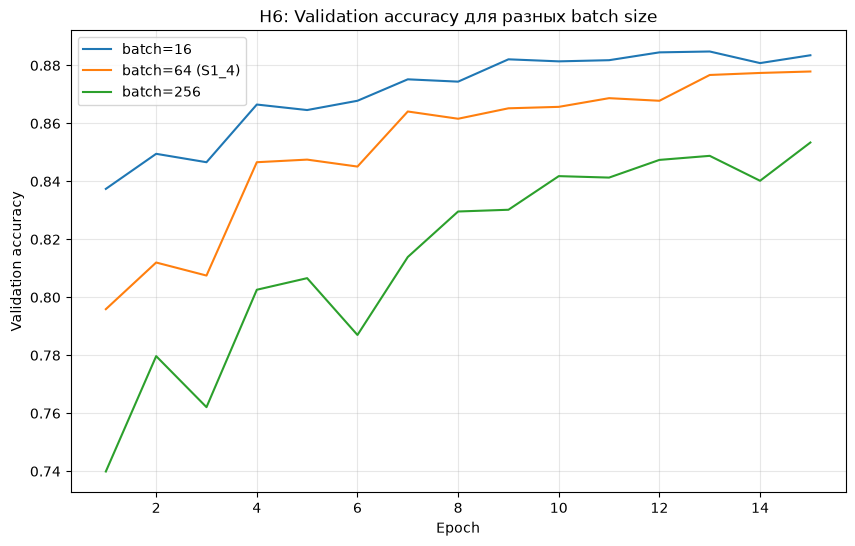

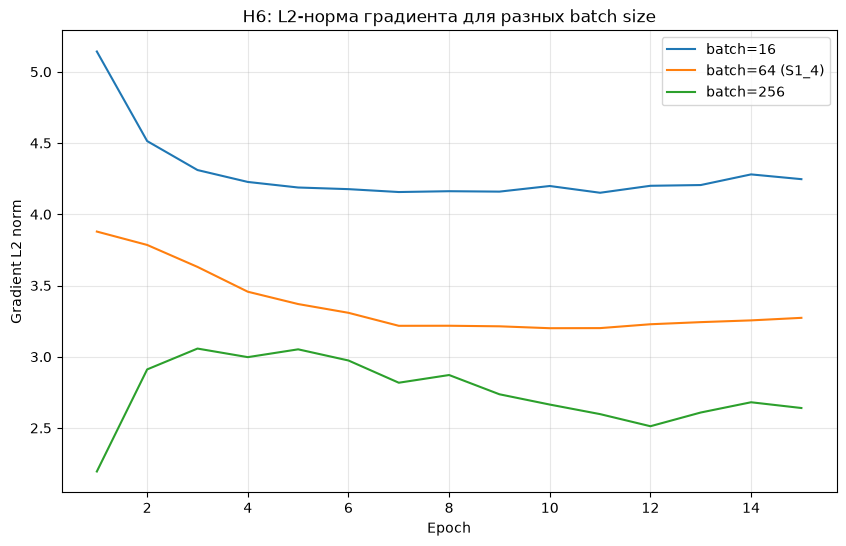

In [20]:
plot_comparison(h6_results, "train_loss", "H6: Train loss для разных batch size", "Train loss")

plot_comparison(h6_results, "val_accuracy", "H6: Validation accuracy для разных batch size", "Validation accuracy")

plot_comparison(h6_results, "train_grad_norm", "H6: L2-норма градиента для разных batch size", "Gradient L2 norm")


In [21]:
def _trajectory_noise(values):
    values = np.asarray(values, dtype=np.float64)

    if len(values) < 2:
        return 0.0

    return float(np.std(np.diff(values)))


def analyze_h6(h6_results):
    noise = {label: _trajectory_noise(result["history"]["train_loss"]) for label, result in h6_results.items()}
    final_acc = {label: result["history"]["val_accuracy"][-1] for label, result in h6_results.items()}

    small_is_noisiest = noise["batch=16"] > noise["batch=64 (S1_4)"] and noise["batch=16"] > noise["batch=256"]

    if small_is_noisiest:
        verdict = "Гипотеза H6 в части более шумной динамики малого batch подтверждается."
    else:
        verdict = "Гипотеза H6 о большей шумности малого batch на этих данных не подтверждается однозначно."

    best_acc = max(final_acc.values())
    acc_gap = best_acc - final_acc["batch=16"]
    quality_text = "При этом batch=16 дал сопоставимое итоговое качество." if acc_gap <= 0.02 else "При этом batch=16 заметно уступил лучшему варианту по accuracy."

    conclusion = (
        f"{verdict} {quality_text} Noise(std(diff(train_loss))): b16={noise['batch=16']:.5f}, "
        f"b64={noise['batch=64 (S1_4)']:.5f}, b256={noise['batch=256']:.5f}. "
        f"Final val accuracy: b16={final_acc['batch=16']:.4f}, b64={final_acc['batch=64 (S1_4)']:.4f}, b256={final_acc['batch=256']:.4f}."
    )

    print(conclusion)
    return conclusion


h6_conclusion = analyze_h6(h6_results)
h6_conclusions = {"H6_batch16": h6_conclusion, "H6_batch64_reuse_S1_4": h6_conclusion, "H6_batch256": h6_conclusion}
h6_df = results_to_dataframe([h6_batch16, h6_batch64, h6_batch256], conclusions=h6_conclusions)
h6_df


Гипотеза H6 о большей шумности малого batch на этих данных не подтверждается однозначно. При этом batch=16 дал сопоставимое итоговое качество. Noise(std(diff(train_loss))): b16=0.02161, b64=0.03367, b256=0.05987. Final val accuracy: b16=0.8835, b64=0.8779, b256=0.8534.


,experiment,hypothesis,role,architecture,init,weight_init_std,activation,bias_init,bias_init_std,batch,...,train_precision,train_recall,train_f1,val_loss,val_accuracy,val_precision,val_recall,val_f1,grad_l2,conclusion
0,H6_batch16,H6,эксперимент: batch=16,"[784, 392, 196, 98, 49, 25, 10]",kaiming,NaN,relu,zero,NaN,16,...,0.932313,0.929233,0.929757,0.346604,0.8835,0.887085,0.8835,0.884291,4.246537,Гипотеза H6 о большей шумности малого batch на...
1,H6_batch64_reuse_S1_4,H6,контроль: batch=64; переиспользован S1_4,"[784, 392, 196, 98, 49, 25, 10]",kaiming,NaN,relu,zero,NaN,64,...,0.910746,0.909617,0.909926,0.349736,0.8779,0.879430,0.8779,0.878454,3.273107,Гипотеза H6 о большей шумности малого batch на...
2,H6_batch256,H6,эксперимент: batch=256,"[784, 392, 196, 98, 49, 25, 10]",kaiming,NaN,relu,zero,NaN,256,...,0.870551,0.871600,0.869955,0.414041,0.8534,0.851659,0.8534,0.851542,2.640232,Гипотеза H6 о большей шумности малого batch на...


# 9. Единая итоговая таблица


In [22]:
final_results = [
    mandatory_results["S1_1"],
    mandatory_results["S1_2"],
    mandatory_results["S1_3"],
    mandatory_results["S1_4"],
    h1_sigmoid,
    h1_tanh,
    h1_relu,
    h4_zero,
    h4_random,
    h6_batch16,
    h6_batch64,
    h6_batch256,
]

final_conclusions = {
    "H1_sigmoid": h1_conclusion,
    "H1_tanh_reuse_S1_3": h1_conclusion,
    "H1_relu": h1_conclusion,
    "H4_bias_zero_reuse_S1_4": h4_conclusion,
    "H4_bias_random": h4_conclusion,
    "H6_batch16": h6_conclusion,
    "H6_batch64_reuse_S1_4": h6_conclusion,
    "H6_batch256": h6_conclusion,
}

final_df = results_to_dataframe(final_results, conclusions=final_conclusions)
history_df = histories_to_dataframe(final_results)

final_df.to_csv("final_results.csv", index=False, encoding="utf-8-sig")
history_df.to_csv("all_training_history.csv", index=False, encoding="utf-8-sig")

print("Сохранено: final_results.csv")
print("Сохранено: all_training_history.csv")

final_df


Сохранено: final_results.csv
Сохранено: all_training_history.csv


,experiment,hypothesis,role,architecture,init,weight_init_std,activation,bias_init,bias_init_std,batch,...,train_precision,train_recall,train_f1,val_loss,val_accuracy,val_precision,val_recall,val_f1,grad_l2,conclusion
0,S1_1,Series 1,обязательная конфигурация,"[784, 100, 50, 10]",normal,0.01,sigmoid,zero,NaN,16,...,0.929562,0.929200,0.929149,0.330851,0.8859,0.886778,0.8859,0.885940,0.976321,обязательная конфигурация
1,S1_2,Series 1,обязательная конфигурация,"[784, 100, 50, 10]",normal,0.01,sigmoid,zero,NaN,32,...,0.531648,0.487100,0.435563,1.365696,0.4851,0.529849,0.4851,0.431154,0.653599,обязательная конфигурация
2,S1_3,Series 1,обязательная конфигурация,"[784, 392, 196, 98, 10]",xavier,NaN,tanh,zero,NaN,32,...,0.899580,0.899667,0.899313,0.350274,0.8756,0.875499,0.8756,0.875192,2.389627,обязательная конфигурация
3,S1_4,Series 1,обязательная конфигурация,"[784, 392, 196, 98, 49, 25, 10]",kaiming,NaN,relu,zero,NaN,64,...,0.910746,0.909617,0.909926,0.349736,0.8779,0.879430,0.8779,0.878454,3.273107,обязательная конфигурация
4,H1_sigmoid,H1,эксперимент: sigmoid,"[784, 392, 196, 98, 10]",xavier,NaN,sigmoid,zero,NaN,32,...,0.773381,0.780900,0.772872,0.620481,0.7737,0.766851,0.7737,0.766939,0.935232,Гипотеза H1 подтверждается. Final val accuracy...
5,H1_tanh_reuse_S1_3,H1,контроль: tanh; переиспользован S1_3,"[784, 392, 196, 98, 10]",xavier,NaN,tanh,zero,NaN,32,...,0.899580,0.899667,0.899313,0.350274,0.8756,0.875499,0.8756,0.875192,2.389627,Гипотеза H1 подтверждается. Final val accuracy...
6,H1_relu,H1,эксперимент: ReLU,"[784, 392, 196, 98, 10]",xavier,NaN,relu,zero,NaN,32,...,0.912948,0.913133,0.912777,0.331024,0.8823,0.882045,0.8823,0.881960,3.086235,Гипотеза H1 подтверждается. Final val accuracy...
7,H4_bias_zero_reuse_S1_4,H4,контроль: b=0; переиспользован S1_4,"[784, 392, 196, 98, 49, 25, 10]",kaiming,NaN,relu,zero,NaN,64,...,0.910746,0.909617,0.909926,0.349736,0.8779,0.879430,0.8779,0.878454,3.273107,Гипотеза H4 подтверждается: нулевые bias не да...
8,H4_bias_random,H4,"эксперимент: b ~ N(0, 0.01)","[784, 392, 196, 98, 49, 25, 10]",kaiming,NaN,relu,random,0.01,64,...,0.912402,0.912250,0.912186,0.341128,0.8797,0.880017,0.8797,0.879611,3.254826,Гипотеза H4 подтверждается: нулевые bias не да...
9,H6_batch16,H6,эксперимент: batch=16,"[784, 392, 196, 98, 49, 25, 10]",kaiming,NaN,relu,zero,NaN,16,...,0.932313,0.929233,0.929757,0.346604,0.8835,0.887085,0.8835,0.884291,4.246537,Гипотеза H6 о большей шумности малого batch на...
